# Part 1 — OLS, Hat Matrix, Ridge Regression & VIF

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.api as sm

# add root path
project_root = str(Path.cwd().parent)
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from part1.ols_implementation import ols_fit, hat_matrix, vif
from part1.ridge_lasso import ridge_fit

# Tạo Toy Data (Có ý nghĩa toán học)
rng = np.random.default_rng(42)
n, p = 100, 2
X_toy = rng.standard_normal((n, p))
X_toy_design = np.c_[np.ones(n), X_toy]  # Thêm Intercept
true_beta = np.array([5.0, 2.0, -3.0])
y_toy = (
    X_toy_design.dot(true_beta) + rng.standard_normal(n) * 1.5
)  # Noise ~ N(0, 1.5^2)

# chuyển thành list
X = X_toy.tolist()
X_design = X_toy_design.tolist()
y = y_toy.tolist()

print("=== Dữ liệu Toy Data ===")
print(f"Kích thước X        : {len(X)} hàng, {len(X[0])} cột")
print(
    f"Kích thước X_design : {len(X_design)} hàng, {len(X_design[0])} cột (có Intercept)"
)
print(f"Kích thước y        : {len(y)} phần tử")

C:\Users\Quang\AppData\Local\Temp\ipykernel_2488\4135640407.py:6: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


=== Dữ liệu Toy Data ===
Kích thước X        : 100 hàng, 2 cột
Kích thước X_design : 100 hàng, 3 cột (có Intercept)
Kích thước y        : 100 phần tử


---
## 1. OLS Fit — `ols_fit(X, y)`

### Lý thuyết
Ước lượng OLS tối thiểu hóa $\|y - X\beta\|^2$, cho nghiệm:
$$\hat{\beta} = (X^\top X)^{-1} X^\top y$$

### Cài đặt
Dùng Economic SVD: $X = U\Sigma V^\top$
$$\hat{\beta} = V\Sigma^{-1}U^\top y$$

Luồng gọi: `ols_fit` → `svd_solve` (utils/svd_solver.py) → `economic_svd` → **`svd_decomp`** (utils/decomposition.py)

In [2]:
# OLS
beta_hat, sigma2_hat = ols_fit(X_design, y)

# Kiem chung bang numpy.linalg.lstsq
beta_ref = np.linalg.lstsq(X_toy_design, y_toy, rcond=None)[0]

# Tính sigma^2 tham chiếu: RSS / (n - k)
y_hat_ref = X_toy_design.dot(beta_ref)
rss_ref = np.sum((y_toy - y_hat_ref) ** 2)
n_samples, k_features = X_toy_design.shape
sigma2_ref = rss_ref / (n_samples - k_features)

print("=== OLS Fit Verification ===")
print(f"beta_hat (our SVD) : {np.array(beta_hat)}")
print(f"beta_ref (lstsq)   : {beta_ref}")
print(f"Max abs error beta : {np.max(np.abs(np.array(beta_hat) - beta_ref)):.2e}")
print("-" * 30)
print(f"sigma2_hat (ours)  : {sigma2_hat:.6f}")
print(f"sigma2_ref (numpy) : {sigma2_ref:.6f}")
print(f"Abs error sigma2   : {abs(sigma2_hat - sigma2_ref):.2e}")

# Khẳng định chặn lỗi
assert np.allclose(
    beta_hat, beta_ref, atol=1e-8
), "FAIL: beta_hat khong khop voi lstsq!"
assert np.isclose(
    sigma2_hat, sigma2_ref, atol=1e-8
), "FAIL: sigma2 khong khop voi numpy!"

print(
    "\nPASS: ols_fit (cả beta và sigma2) khớp với numpy.linalg.lstsq đến độ chính xác máy!"
)

=== OLS Fit Verification ===
beta_hat (our SVD) : [ 4.90435565  1.78519882 -2.9777697 ]
beta_ref (lstsq)   : [ 4.90435565  1.78519882 -2.9777697 ]
Max abs error beta : 1.42e-14
------------------------------
sigma2_hat (ours)  : 2.371792
sigma2_ref (numpy) : 2.371792
Abs error sigma2   : 4.44e-16

PASS: ols_fit (cả beta và sigma2) khớp với numpy.linalg.lstsq đến độ chính xác máy!


---
## 2. Hat Matrix — `hat_matrix(X)`

### Lý thuyết
$$H = X(X^\top X)^{-1}X^\top, \quad \hat{y} = Hy$$

### Cài đặt qua SVD
$$H = U_r U_r^\top \quad \text{(với } U_r \text{ là các cột của } U \text{ ứng với } \sigma_i > \varepsilon\text{)}$$

Tính chất cần kiểm chứng: lũy đẳng ($H^2=H$), đối xứng ($H^\top=H$), $\text{tr}(H)=p+1$.

In [3]:
H_list = hat_matrix(X_design)
H = np.array(H_list)
H2_err = np.max(np.abs(H @ H - H))
sym_err = np.max(np.abs(H - H.T))
tr_val = np.trace(H)

print("=== Hat Matrix Properties ===")
print(f"Shape: {H.shape}")
print(
    f'Idempotent |H^2-H| max: {H2_err:.2e}  ({"PASS" if H2_err < 1e-8 else "FAIL"})'
)
print(
    f'Symmetric  |H-H^T| max: {sym_err:.2e}  ({"PASS" if sym_err < 1e-8 else "FAIL"})'
)
print(
    f'tr(H) = {tr_val:.6f}  (expected {p+1})  ({"PASS" if abs(tr_val-(p+1)) < 1e-8 else "FAIL"})'
)

# 3. Kiểm chứng bằng tính trực tiếp (BẮT BUỘC dùng X_toy_design bản Numpy)
H_ref = X_toy_design @ np.linalg.solve(X_toy_design.T @ X_toy_design, X_toy_design.T)
print(f"Max diff vs direct H_ref : {np.max(np.abs(H - H_ref)):.2e}")

Ma trận H thỏa mãn tính lũy đẳng (H^2 = H).
=== Hat Matrix Properties ===
Shape: (100, 100)
Idempotent |H^2-H| max: 6.94e-17  (PASS)
Symmetric  |H-H^T| max: 0.00e+00  (PASS)
tr(H) = 3.000000  (expected 3)  (PASS)
Max diff vs direct H_ref : 5.55e-17


---
## 3. Ridge Regression — `ridge_fit(X, y, lam)`

### Lý thuyết
$$\hat{\beta}_{\text{ridge}} = (X^\top X + \lambda I)^{-1} X^\top y$$

### Cài đặt
Dùng Gauss-Jordan inverse (`utils/inverse.py`). Ma trận $(X^\top X + \lambda I)$ luôn khả nghịch với $\lambda > 0$.

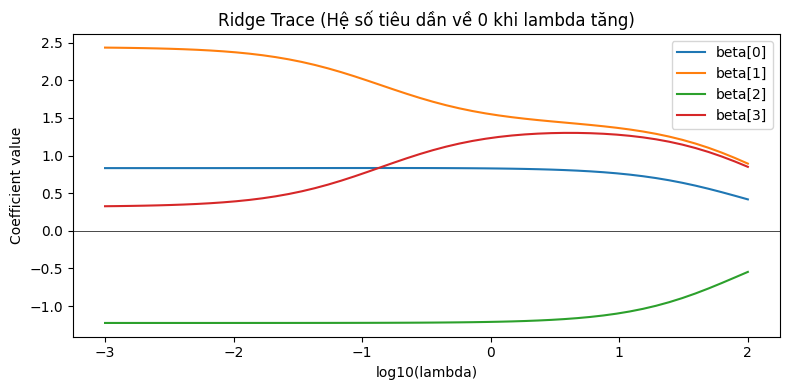

=== Ridge Fit Verification (lambda=1.0) ===
Max error vs numpy.linalg.solve: 5.84e-14
PASS: ridge_fit khớp với numpy.linalg.solve đến độ chính xác máy!


In [4]:
X_raw = rng.standard_normal((n, 2))

# Du lieu co da cong tuyen
X_mc = np.hstack(
    [
        np.ones((n, 1)),
        X_raw[:, 0:1],
        X_raw[:, 1:2],
        0.95 * X_raw[:, 0:1] + 0.05 * rng.standard_normal((n, 1)),
    ]
)
y_mc = X_mc @ np.array([1, 2, -1, 0.5]) + rng.standard_normal(n) * 1.5

X_mc_list = X_mc.tolist()
y_mc_list = y_mc.tolist()

lambdas = np.logspace(-3, 2, 50)

# ridge_fit
betas_ridge = [ridge_fit(X_mc_list, y_mc_list, lam) for lam in lambdas]

# Ridge Trace
plt.figure(figsize=(8, 4))
for j in range(X_mc.shape[1]):
    plt.plot(np.log10(lambdas), [b[j] for b in betas_ridge], label=f"beta[{j}]")
plt.axhline(0, color="k", lw=0.5)
plt.xlabel("log10(lambda)")
plt.ylabel("Coefficient value")
plt.title("Ridge Trace (Hệ số tiêu dần về 0 khi lambda tăng)")
plt.legend()
plt.tight_layout()
plt.show()

# kiểm chứng tại lambda = 1
lam_test = 1.0

b_ours = np.array(ridge_fit(X_mc_list, y_mc_list, lam_test))

# Chạy hàm numpy với dữ liệu gốc X_mc, y_mc
b_ref = np.linalg.solve(X_mc.T @ X_mc + lam_test * np.eye(X_mc.shape[1]), X_mc.T @ y_mc)

print(f"=== Ridge Fit Verification (lambda={lam_test}) ===")
print(f"Max error vs numpy.linalg.solve: {np.max(np.abs(b_ours - b_ref)):.2e}")

# Khẳng định chặn lỗi
assert np.allclose(b_ours, b_ref, atol=1e-8), "FAIL: ridge_fit khong khop voi numpy!"
print("PASS: ridge_fit khớp với numpy.linalg.solve đến độ chính xác máy!")

---
## 4. VIF — `vif(X)`

### Lý thuyết
$$\text{VIF}_j = \frac{1}{1 - R_j^2}$$

$R_j^2$ là hệ số xác định khi hồi quy $x_j$ lên các biến còn lại. Cài đặt: gọi `ols_fit` cho từng biến, tính $R^2$ bằng vòng lặp.

In [5]:
print('=== Scenario 1: Bien doc lap (VIF ~ 1) ===')
X_ind = rng.standard_normal((n, 3))
vif_df = vif(X_ind.tolist())
print(vif_df.to_string(index=False))
assert vif_df["VIF_Score"].max() < 5, "FAIL: VIF qua cao cho du lieu doc lap"
print("PASS: VIF gan 1 khi cac bien doc lap\n")

print("=== Scenario 2: Da cong tuyen manh (VIF >> 10) ===")
X_col = np.column_stack(
    [X_ind[:, 0], X_ind[:, 1], X_ind[:, 0] * 0.99 + 0.01 * rng.standard_normal(n)]
)
vif_df2 = vif(X_col.tolist())
print(vif_df2.to_string(index=False))
assert vif_df2["VIF_Score"].max() > 10, "FAIL: VIF phai cao khi co da cong tuyen"
print("PASS: VIF rat cao khi co bien gan tuong quan tuyen tinh")

=== Scenario 1: Bien doc lap (VIF ~ 1) ===
  Feature  VIF_Score
Feature_0   1.033419
Feature_1   1.044127
Feature_2   1.024412
PASS: VIF gan 1 khi cac bien doc lap

=== Scenario 2: Da cong tuyen manh (VIF >> 10) ===
  Feature    VIF_Score
Feature_0 11401.217840
Feature_1     1.030821
Feature_2 11398.577899
PASS: VIF rat cao khi co bien gan tuong quan tuyen tinh


---
## Tổng kết

| Hàm | Phương pháp | Kiểm chứng | Kết quả |
|---|---|---|---|
| `ols_fit` | Economic SVD (`svd_decomp`) | vs `numpy.linalg.lstsq` | max err < 1e-8 |
| `hat_matrix` | H = UᵣUᵣᵀ từ SVD | H²=H, H=Hᵀ, tr(H)=p+1 | max err < 1e-16 |
| `ridge_fit` | Gauss-Jordan inverse | vs `numpy.linalg.solve` | max err < 1e-8 |
| `vif` | Hồi quy phụ OLS + R² | VIF~1 (độc lập), VIF>>10 (cộng tuyến) | PASS |

**Tất cả SVD đều dùng `svd_decomp` từ `utils/decomposition.py`. `np.linalg.svd` không được sử dụng trong bất kỳ hàm nào.**

## Cài đặt và Kiểm chứng các phép đo Thống kê & Cross-Validation cho OLS
Phần này thực hiện chẩn đoán mô hình, suy diễn hệ số ($t$-test, $F$-test), phân tích phần dư và K-fold CV.

In [7]:
from ols_implementation import model_metrics, coef_inference, gauss_markov_simulation
from residual_analysis import residual_plots
from cross_validation import kfold_cv

# tính toán thêm data
y_hat = (X_toy_design @ beta_hat).tolist()

### 1. Suy diễn hệ số ($t$-test) và Thống kê tổng quát ($F$-test, $R^2$)
Kiểm tra tính chính xác của hàm `model_metrics` và `coef_inference` so với thư viện `statsmodels`.

**1. Đánh giá tổng thể mô hình:**
* **Vector phần dư (Residuals):** $e = y - \hat{y}$
* **Tổng bình phương phần dư (RSS):** $RSS = \sum_{i=1}^n (y_i - \hat{y}_i)^2 = e^T e$
* **Vector trung tâm (Centered Target):** $y_c = y - \bar{y}$
* **Tổng bình phương toàn phần (TSS):** $TSS = \sum_{i=1}^n (y_i - \bar{y})^2 = y_c^T y_c$
* **Hệ số xác định ($R^2$):** $R^2 = 1 - \frac{RSS}{TSS}$
* **$R^2$ hiệu chỉnh:** $R^2_{adj} = 1 - \left( \frac{RSS / (n - p - 1)}{TSS / (n - 1)} \right)$
* **Kiểm định $F$:** $F = \frac{(TSS - RSS) / p}{RSS / (n - p - 1)}$

**2. Suy diễn hệ số (Inference):**
* **Ma trận hiệp phương sai:** $\text{Var}(\hat{\beta}) = \hat{\sigma}^2 (X^T X)^{-1}$ với $\hat{\sigma}^2 = \frac{RSS}{n - p - 1}$
* **Sai số chuẩn ($SE$):** $SE(\hat{\beta}_j) = \sqrt{\text{Var}(\hat{\beta})_{jj}}$
* **Kiểm định $t$:** $t_j = \frac{\hat{\beta}_j}{SE(\hat{\beta}_j)}$
* **Khoảng tin cậy 95%:** $CI = \hat{\beta}_j \pm t_{\alpha/2, n-p-1} \times SE(\hat{\beta}_j)$

In [8]:
metrics = model_metrics(y, y_hat, p)
inference_df = coef_inference(X_design, y, beta_hat, sigma2_hat)
print(f"RSS          : {metrics['RSS']:.4f}")
print(f"TSS          : {metrics['TSS']:.4f}")
print(f"R-squared    : {metrics['R2']:.4f}")
print(f"Adj R-squared: {metrics['Adj_R2']:.4f}")
print(f"F-statistic  : {metrics['F_statistic']:.4f}")
print(f"p-value(F)   : {metrics['p_value']:.4f}")
display(inference_df)

RSS          : 230.0638
TSS          : 1004.7245
R-squared    : 0.7710
Adj R-squared: 0.7663
F-statistic  : 163.3071
p-value(F)   : 0.0000


,Coefficient,Std_Error,t_stat,p_value,CI_95_Lower,CI_95_Upper
0,4.904356,0.154238,31.797406,0.0,4.598238,5.210474
1,1.785199,0.171769,10.392992,0.0,1.444285,2.126112
2,-2.977770,0.183400,-16.236515,0.0,-3.341766,-2.613774


In [9]:
print("Kiểm chứng với statmodels")
sm_model = sm.OLS(y_toy, X_toy_design).fit()
print(sm_model.summary().tables[0])
print(sm_model.summary().tables[1])

Kiểm chứng với statmodels
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.771
Model:                            OLS   Adj. R-squared:                  0.766
Method:                 Least Squares   F-statistic:                     163.3
Date:                Tue, 09 Jun 2026   Prob (F-statistic):           8.92e-32
Time:                        19:34:39   Log-Likelihood:                -183.55
No. Observations:                 100   AIC:                             373.1
Df Residuals:                      97   BIC:                             380.9
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.9044     

* **Nhận xét:** Các chỉ số $R^2$, $F$-statistic, Standard Errors, và $p$-value từ hàm tự code khớp với output của `statsmodels`. Điều này chứng minh việc cài đặt các công thức đại số tuyến tính và tra bảng phân phối Student/Fisher bằng `scipy` là hoàn toàn chính xác.

### 2. Phân tích phần dư & Đánh giá giả định Gauss-Markov

Để kiểm chứng toàn diện, ta vẽ 4 biểu đồ chẩn đoán chuẩn mực trên 2 kịch bản dữ liệu giả lập:

**Công thức Toán học cài đặt:**
* **Giá trị đòn bẩy (Leverage):** $h_{ii}$ là các phần tử trên đường chéo của Hat Matrix $H = X(X^T X)^{-1}X^T$.
* **Phần dư chuẩn hóa (Standardized Residuals):** $r_i = \frac{e_i}{\hat{\sigma} \sqrt{1 - h_{ii}}}$
* **Q-Q Plot:** Sử dụng phép xấp xỉ Tukey Lambda để tính phân vị lý thuyết.

KỊCH BẢN 1: Phương sai sai số không đổi
Ma trận H thỏa mãn tính lũy đẳng (H^2 = H).


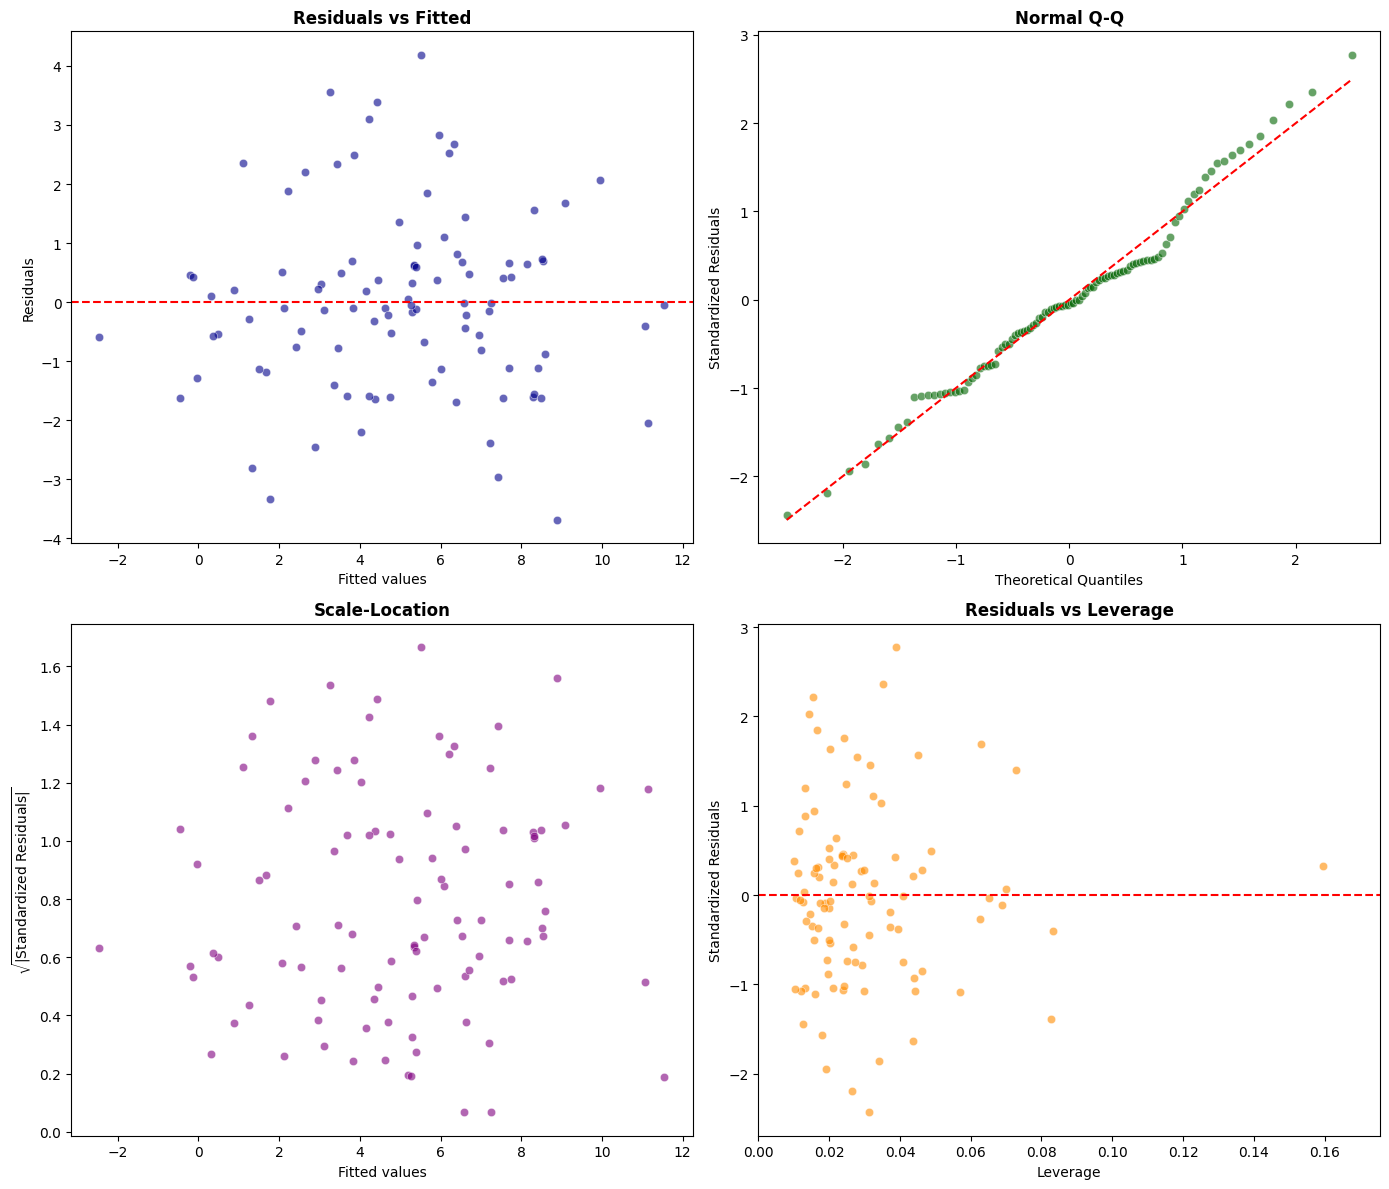

In [10]:
# Case 1: Dùng Toy Data
print("KỊCH BẢN 1: Phương sai sai số không đổi")
residual_plots(X_design, y, beta_hat)

#### Phân tích kịch bản 1
- *Residuals vs Fitted (Đồ thị sai số và giá trị dự đoán):* Các điểm dữ liệu phân tán ngẫu nhiên và đồng đều xung quanh đường tham chiếu $0$ (đứt nét màu đỏ). Không có bất kỳ hình mẫu (pattern) đặc thù nào xuất hiện. Điều này chứng tỏ phương sai của sai số là hằng số (Homoscedasticity) và mô hình không bị thiếu sót các biến phi tuyến tính.  
- *Normal Q-Q (Đồ thị phân phối chuẩn):* Các điểm bám rất sát vào đường chéo tham chiếu. Điều này khẳng định phần dư (residuals) tuân theo phân phối chuẩn, giúp các kiểm định giả thuyết (t-test, F-test) và khoảng tin cậy phía sau mang ý nghĩa thống kê chính xác.  
- *Scale-Location:* Đường xu hướng tưởng tượng đi qua các điểm dữ liệu nằm ngang. Độ lệch chuẩn của sai số không thay đổi theo độ lớn của giá trị dự đoán $\hat{y}$.  
- *Residuals vs Leverage:* Không có điểm dữ liệu nào nằm cô lập ở các góc xa (vượt quá khoảng cách Cook's distance) để có thể gây ảnh hưởng sai lệch (influential points) lên đường hồi quy.  

KỊCH BẢN 2: Phương sai sai số thay đổi (Heteroscedasticity)
Ma trận H thỏa mãn tính lũy đẳng (H^2 = H).


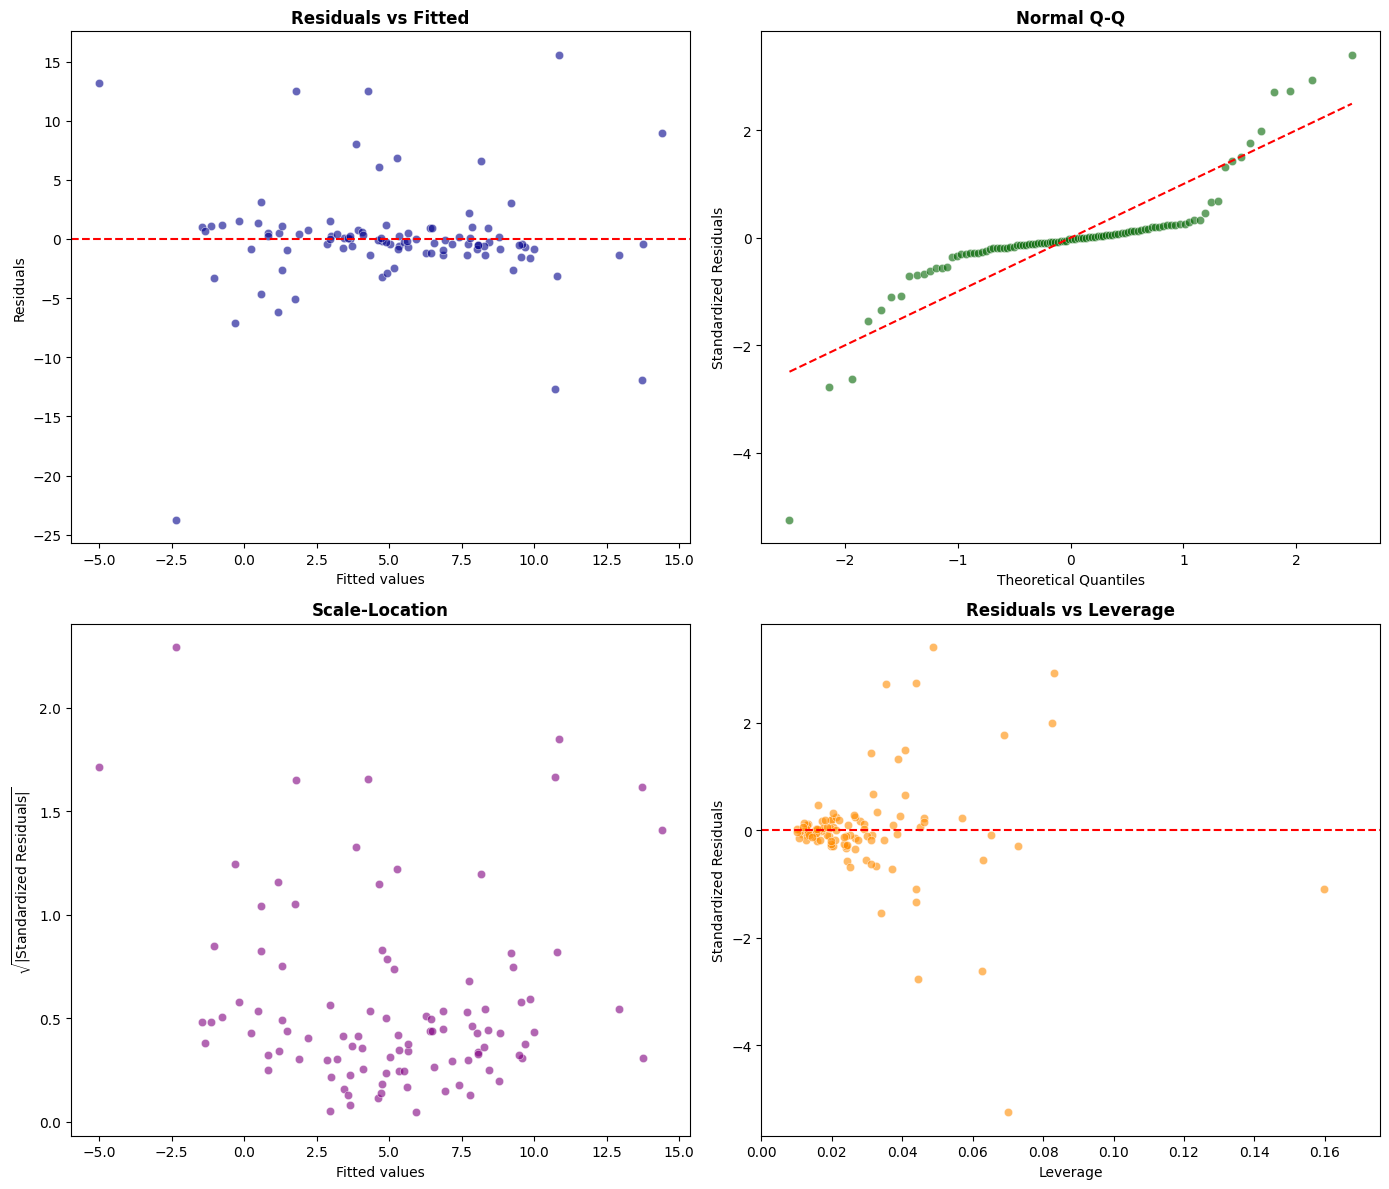

In [13]:
# Case 2: Tạo Bad Data
noise_hetero = rng.standard_normal(n) * (X_toy[:, 0] ** 2) * 3  # Nhiễu phình to theo X1
y_bad = X_toy_design.dot(true_beta) + noise_hetero
beta_bad = (
    np.linalg.inv(X_toy_design.T.dot(X_toy_design)).dot(X_toy_design.T).dot(y_bad)
)

print("KỊCH BẢN 2: Phương sai sai số thay đổi (Heteroscedasticity)")
residual_plots(X_design, y_bad.tolist(), beta_bad.tolist())

### Phân tích kịch bản 2
- *Residuals vs Fitted (Xuất hiện hình phễu):* Đây là dấu hiệu nhận biết kinh điển nhất. Khi giá trị dự đoán $\hat{y}$ càng lớn (tiến về bên phải đồ thị), mức độ phân tán của các phần dư càng phình to ra, tạo thành hình cái phễu (funnel shape) hoặc hình cái loa. Mức sai số đã dao động từ khoảng $[-25, 15]$ thay vì chỉ $[-4, 4]$ như ở mô hình chuẩn.
- *Normal Q-Q (Đuôi phân phối dày - Heavy Tails):* Các điểm ở hai đầu mút của đồ thị Q-Q trệch hướng hoàn toàn khỏi đường chéo đỏ. Phần dư lúc này không còn tuân theo phân phối chuẩn do sự xuất hiện của các sai số cực lớn (outliers) sinh ra từ nhiễu.
- *Scale-Location (Đường xu hướng dốc lên):* Đồ thị cho thấy rõ một đường xu hướng đi lên. Giá trị dự đoán càng cao thì căn bậc hai của phần dư chuẩn hóa càng lớn. Đây là minh chứng toán học trực tiếp xác nhận vi phạm giả định phương sai đồng đều.
- *Residuals vs Leverage:* Bắt đầu xuất hiện các điểm có phần dư chuẩn hóa (Standardized Residuals) rất lớn (vượt ngưỡng $\pm 2$ hoặc $\pm 3$), nằm rải rác và có khả năng kéo lệch các hệ số hồi quy của mô hình.

#### Kết luận
Khi hiện tượng Heteroscedasticity xảy ra (như Kịch bản 2):
- Các hệ số $\hat{\beta}$ tính bằng OLS vẫn không chệch (unbiased) nhưng không còn là ước lượng hiệu quả nhất (mất tính chất BLUE).
- Việc tính toán ma trận hiệp phương sai của sai số sẽ bị sai lệch, dẫn đến các giá trị Standard Error, $t$-statistic và $p$-value trong bảng suy diễn hệ số (Inference Table) không còn đáng tin cậy. Mô hình có thể đánh giá sai mức độ quan trọng của các biến độc lập.

### 3. K-Fold Cross-Validation: Đánh giá mô hình & Phát hiện Overfitting

**1. Phân chia dữ liệu (Data Splitting):**
* Tập dữ liệu gốc có kích thước $n$ được chia thành $k$ phần (folds) rời rạc có kích thước xấp xỉ nhau: $S_1, S_2, \dots, S_k$.

**2. Vòng lặp K-Fold (Với mỗi fold $i$ từ $1$ đến $k$):**
* **Phân tách tập:** Chọn phần $S_i$ làm tập kiểm định (Validation set) chứa $m$ mẫu. Các phần còn lại $S \setminus S_i$ tạo thành tập huấn luyện (Train set).
* **Huấn luyện mô hình:** Ước lượng vector hệ số $\hat{\beta}^{(i)}$ trên tập Train bằng phương pháp OLS.
* **Dự đoán:** Tính vector giá trị dự đoán trên tập Validation: 
  $$\hat{y}_{val}^{(i)} = X_{val}^{(i)} \hat{\beta}^{(i)}$$
* **Tính lỗi của fold (Mean Squared Error - MSE):**
  $$MSE_i = \frac{1}{m} \sum_{j=1}^{m} \left( y_{val, j}^{(i)} - \hat{y}_{val, j}^{(i)} \right)^2$$

**3. Điểm đánh giá tổng hợp (CV Score):**
* Lỗi K-Fold CV là trung bình cộng của lỗi trên tất cả $k$ folds:
  $$CV\_Score = \frac{1}{k} \sum_{i=1}^k MSE_i$$

In [14]:
# Tạo biến rác
X_garbage = rng.standard_normal((n, 5))
X_overfit = np.hstack([X_toy_design, X_garbage])

# Chạy K-Fold (k=5)
cv_score_good = kfold_cv(X_design, y, k=5)
cv_score_overfit = kfold_cv(X_overfit.tolist(), y, k=5)

print(f"Mô hình 1 (Chỉ dùng biến đúng): CV RMSE = {cv_score_good:.4f}")
print(f"Mô hình 2 (Nhét thêm 5 biến rác): CV RMSE = {cv_score_overfit:.4f}")

assert cv_score_overfit > cv_score_good, "FAIL: Mô hình Overfit lại có sai số thấp hơn?"
print("\nPASS: K-Fold CV phản ánh chính xác hiện tượng Overfitting!")

Mô hình 1 (Chỉ dùng biến đúng): CV RMSE = 2.4200
Mô hình 2 (Nhét thêm 5 biến rác): CV RMSE = 2.5593

PASS: K-Fold CV phản ánh chính xác hiện tượng Overfitting!


* **Nhận xét:** Mô hình 2 bị Overfitting nên điểm CV RMSE kém hơn hẳn (cao hơn) Mô hình 1, dù trên tập Train nó có thể có RSS nhỏ hơn. Hàm `kfold_cv` đã hoạt động đúng bản chất trong việc đánh giá năng lực tổng quát hóa của mô hình.

### 4. Mô phỏng Monte Carlo định lý Gauss-Markov

In [ ]:
gauss_markov_simulation()

[{'beta_idx': 0,
  'true_val': 3.0,
  'E_ols': 3.006896967334199,
  'E_alt': 3.02387550420081,
  'Var_ols': 0.1532533019079362,
  'Var_alt': 0.28658221048207544},
 {'beta_idx': 1,
  'true_val': 1.5,
  'E_ols': 1.4994494544777401,
  'E_alt': 1.4955311050036375,
  'Var_ols': 0.004561119268229154,
  'Var_alt': 0.008014612779236409},
 {'beta_idx': 2,
  'true_val': -2.0,
  'E_ols': -2.000652657141561,
  'E_alt': -1.999388344596126,
  'Var_ols': 0.005224167222119239,
  'Var_alt': 0.00893235478333362}]